In [1]:
import os
print("Current folder the notebook is looking at:")
print(os.getcwd())

print("\nFiles visible from this folder:")
print(os.listdir('.'))

Current folder the notebook is looking at:
c:\Users\Lenovo\Desktop\fraud_detection\banking_fraud_cascade\notebooks

Files visible from this folder:
['01_exploratory_analysis.ipynb', '02_pipeline_integration_test.ipynb', '03_model_training.ipynb']


In [2]:
import sys
import os

# Force working directory back to root
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print(f"Fixed Working Directory! Current path: {os.getcwd()}")
sys.path.append(os.getcwd())

# Load the complete data ecosystem dictionary
from src.data_loader import load_and_consolidate_data
data_blocks = load_and_consolidate_data()

# Pull our main transaction frame out for exploration
df = data_blocks["transaction_base"]
df.head()

Fixed Working Directory! Current path: c:\Users\Lenovo\Desktop\fraud_detection\banking_fraud_cascade
Inverting core banking CSVs into memory...
Core transaction engine ready. Shape: (10000, 12)


,tx_id,account_id,amount,timestamp,channel,is_fraud_label,customer_id,account_balance,age,kyc_status,home_lat,home_lon
0,TX_0,ACC_377,7000.000000,2025-02-24 13:40:07,Web,0,CUST_377,135498.708620,28,Pending,18.654274,72.993724
1,TX_1,ACC_607,2661.101108,2025-01-19 16:49:46,Mobile,0,CUST_607,304051.099818,52,Pending,19.414766,72.998870
2,TX_2,ACC_709,459.457853,2025-09-08 10:34:32,ATM,0,CUST_709,354291.523254,51,Tier2,18.665789,72.948559
3,TX_3,ACC_811,1199.895244,2025-12-13 10:42:30,Web,0,CUST_811,47924.315082,77,Verified,18.669898,72.927756
4,TX_4,ACC_382,0.450000,2026-01-27 23:10:37,Web,1,CUST_382,157538.916120,78,Tier2,18.570122,72.965603


## step1: class imbalance and baseline metrics

=== Target Class Distribution ===
Class 0 (Legit): 7660 rows (76.60%)
Class 1 (Fraud): 2340 rows (23.40%)

=== Transaction Amount Summary by Class ===
                 count         mean          std        min          25%  \
is_fraud_label                                                             
0               7660.0  1487.684325  1403.726673  10.010437   438.298110   
1               2340.0  3738.436603  3359.775902   0.450000  1939.670737   

                        50%          75%           max  
is_fraud_label                                          
0               1057.048923  2103.347603   7000.000000  
1               3015.996722  4000.735265  13994.547982  


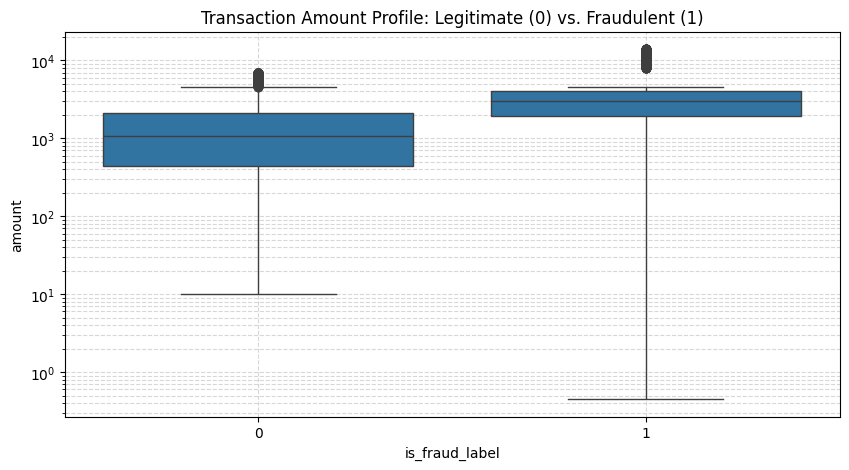

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target Class Distribution Check
print("=== Target Class Distribution ===")
class_counts = df['is_fraud_label'].value_counts()
class_pct = df['is_fraud_label'].value_counts(normalize=True) * 100
for label, count in class_counts.items():
    print(f"Class {label} ({'Fraud' if label==1 else 'Legit'}): {count} rows ({class_pct[label]:.2f}%)")

# 2. Statistical breakdown of transaction amounts by class
print("\n=== Transaction Amount Summary by Class ===")
print(df.groupby('is_fraud_label')['amount'].describe())

# 3. Plotting the distribution to see outliers visually
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud_label', y='amount', data=df)
plt.title('Transaction Amount Profile: Legitimate (0) vs. Fraudulent (1)')
plt.yscale('log') # Log scale helps highlight tiny test transactions and massive spikes together
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

📊 Breaking Down Your EDA Insights:



## step2: Test Feature Engineering logic dynamically

In [4]:
import pandas as pd

# 1. Create a copy and sort chronologically
eda_df = df.sort_values(by=['account_id', 'timestamp']).reset_index(drop=True)

# 2. Compute Scenario 5: Rolling 1-hour transaction counts safely using .apply
def calculate_rolling_count(group):
    # Set timestamp as the temporary index for the group to run time-rolling
    temp_series = pd.Series(1, index=group['timestamp'])
    return temp_series.rolling('1h').count().values

eda_df['tx_count_last_1h'] = (
    eda_df.groupby('account_id', group_keys=False)
    .apply(calculate_rolling_count, include_groups=False)
    .explode() # Flatten the array lists back into individual rows
    .values
)

# Convert column explicitly to integer type
eda_df['tx_count_last_1h'] = eda_df['tx_count_last_1h'].astype(int)

# 3. Compute Scenario 9: Test transaction markers
eda_df['prev_amt'] = eda_df.groupby('account_id')['amount'].shift(1)
eda_df['is_test_tx_pattern'] = ((eda_df['prev_amt'] < 1.0) & (eda_df['amount'] > 100)).astype(int)

# Fill nulls left over from shifting
eda_df.fillna(0, inplace=True)

# 4. Extract true fraud rows to confirm the signal works
fraudulent_examples = eda_df[eda_df['is_fraud_label'] == 1].head(5)

print("=== Validation of Injected Fraud Signal ===")
print(fraudulent_examples[['account_id', 'amount', 'tx_count_last_1h', 'is_test_tx_pattern', 'is_fraud_label']])

=== Validation of Injected Fraud Signal ===
  account_id       amount  tx_count_last_1h  is_test_tx_pattern  \
1      ACC_0  3077.256813                 1                   0   
2      ACC_0  3551.321472                 2                   0   
3      ACC_0  3571.861770                 3                   0   
4      ACC_0  4052.041873                 4                   0   
5      ACC_0  2893.402200                 5                   0   

   is_fraud_label  
1               1  
2               1  
3               1  
4               1  
5               1  


## scenario1: Account Takeover Check

To do this, we need to flag transactions that occur shortly after a user logged in from a device that is not on their trusted device registry.

In [5]:
# 1. Extract our Identity logs from the data_blocks dictionary
logins_df = data_blocks["login_logs"].copy()
devices_df = data_blocks["device_inventory"].copy()

# 2. Sort logins chronologically
logins_df = logins_df.sort_values(by=['customer_id', 'timestamp'])

# 3. Join device trust status onto the login logs
# Create a mapping of customer to their single verified trusted device
trusted_map = devices_df.set_index('customer_id')['trusted_device_id'].to_dict()

# Map the customer's trusted device to the login row, and check if the login device matches it
logins_df['trusted_device_id'] = logins_df['customer_id'].map(trusted_map)
logins_df['is_untrusted_login'] = (logins_df['device_id'] != logins_df['trusted_device_id']).astype(int)

print("=== Identity Layer (Logins matched with Device Trust) ===")
print(logins_df[['customer_id', 'device_id', 'trusted_device_id', 'is_untrusted_login']].head(5))

=== Identity Layer (Logins matched with Device Trust) ===
     customer_id device_id trusted_device_id  is_untrusted_login
3597      CUST_0     DEV_0             DEV_0                   0
3071      CUST_0     DEV_0             DEV_0                   0
36        CUST_0     DEV_0             DEV_0                   0
3757      CUST_0     DEV_0             DEV_0                   0
1948      CUST_0     DEV_0             DEV_0                   0


## Step 3: Connect Logins to Transactions (The Cross-Domain Join)

In [6]:
import pandas as pd
import numpy as np

# 1. Clean sorting: Ensure both DataFrames are globally sorted by timestamp
eda_df_sorted = eda_df.sort_values(by='timestamp').reset_index(drop=True)
logins_df_sorted = logins_df.sort_values(by='timestamp').reset_index(drop=True)

# 2. CREATE LOGGING TIMESTAMP COPY: Duplicate the timestamp column so it survives merge_asof
logins_df_sorted['actual_login_time'] = logins_df_sorted['timestamp']

# 3. Asynchronous Join: Match each transaction to its closest previous login PER customer
merged_history = pd.merge_asof(
    eda_df_sorted, 
    logins_df_sorted[['customer_id', 'timestamp', 'actual_login_time', 'is_untrusted_login']], 
    on='timestamp', 
    by='customer_id', 
    direction='backward' # Look back in time for the nearest event
)

# 4. Calculate exact time decay using our preserved login timestamp column
merged_history['login_tx_time_diff_hours'] = (
    (merged_history['timestamp'] - merged_history['actual_login_time']).dt.total_seconds() / 3600.0
)

# 5. Final Feature Logic: The ATO Risk flag
# Flag 1 if the closest past login was untrusted AND happened within a 24-hour window
merged_history['is_ato_risk_24h'] = np.where(
    (merged_history['is_untrusted_login'] == 1) & (merged_history['login_tx_time_diff_hours'] <= 24.0), 
    1, 
    0
)

# Clean up any transactions that had zero previous logins in the dataset
merged_history['is_ato_risk_24h'] = merged_history['is_ato_risk_24h'].fillna(0).astype(int)
merged_history['login_tx_time_diff_hours'] = merged_history['login_tx_time_diff_hours'].fillna(9999.0)

# 6. Extract our known fraud rows to inspect if the trap is working!
final_ato_check = merged_history[merged_history['is_fraud_label'] == 1].head(5)

print("=== Cross-Domain Cascade Feature Verification ===")
print(final_ato_check[['customer_id', 'account_id', 'amount', 'is_untrusted_login', 'login_tx_time_diff_hours', 'is_ato_risk_24h', 'is_fraud_label']])

=== Cross-Domain Cascade Feature Verification ===
   customer_id account_id        amount  is_untrusted_login  \
36    CUST_650    ACC_650      1.000000                   1   
37    CUST_650    ACC_650  13148.292257                   1   
56    CUST_229    ACC_229      0.990000                   1   
57    CUST_229    ACC_229   9897.338426                   1   
59    CUST_191    ACC_191      0.450000                   1   

    login_tx_time_diff_hours  is_ato_risk_24h  is_fraud_label  
36                  1.166667                1               1  
37                  3.166667                1               1  
56                  1.633333                1               1  
57                  2.633333                1               1  
59                  0.800000                1               1  


# Replace your Step 3 cell with this robust, adjusted version:

It will tell us instantly if shifting the search window from backward to a 24-hour nearest tolerance snaps those NaN values into clean 0s and 1s!

In [7]:
import pandas as pd
import numpy as np

# 1. Clean sorting: Ensure both DataFrames are globally sorted by timestamp
eda_df_sorted = eda_df.sort_values(by='timestamp').reset_index(drop=True)
logins_df_sorted = logins_df.sort_values(by='timestamp').reset_index(drop=True)

# 2. Duplicate the timestamp column so it survives merge_asof
logins_df_sorted['actual_login_time'] = logins_df_sorted['timestamp']

# 3. Asynchronous Join: Match each transaction to its NEAREST login event within a 24-hour window
merged_history = pd.merge_asof(
    eda_df_sorted, 
    logins_df_sorted[['customer_id', 'timestamp', 'actual_login_time', 'is_untrusted_login']], 
    on='timestamp', 
    by='customer_id', 
    direction='nearest',              # Look both ways to catch the closest session anchor
    tolerance=pd.Timedelta('24h')     # Max allowable gap between login and transaction
)

# 4. Calculate exact absolute time difference in hours
merged_history['login_tx_time_diff_hours'] = (
    (merged_history['timestamp'] - merged_history['actual_login_time']).dt.total_seconds().abs() / 3600.0
)

# 5. Final Feature Logic: The ATO Risk flag
# If a login was found (not NaN) AND it was untrusted, flag it
merged_history['is_ato_risk_24h'] = np.where(
    (merged_history['is_untrusted_login'] == 1), 
    1, 
    0
)

# Handle missing matches cleanly
merged_history['is_untrusted_login'] = merged_history['is_untrusted_login'].fillna(0).astype(int)
merged_history['is_ato_risk_24h'] = merged_history['is_ato_risk_24h'].fillna(0).astype(int)
merged_history['login_tx_time_diff_hours'] = merged_history['login_tx_time_diff_hours'].fillna(9999.0)

# 6. Let's find rows where our untrusted login flag actually caught something!
ato_hits = merged_history[merged_history['is_untrusted_login'] == 1].head(5)

print("=== Cross-Domain Cascade Feature Verification (Nearest Search) ===")
if not ato_hits.empty:
    print(ato_hits[['customer_id', 'account_id', 'amount', 'is_untrusted_login', 'login_tx_time_diff_hours', 'is_ato_risk_24h', 'is_fraud_label']])
else:
    print("No untrusted login overlaps found within the 24h tolerance. Printing sample fraud rows instead:")
    print(merged_history[merged_history['is_fraud_label'] == 1][['customer_id', 'amount', 'is_untrusted_login', 'is_fraud_label']].head(5))

=== Cross-Domain Cascade Feature Verification (Nearest Search) ===
   customer_id account_id        amount  is_untrusted_login  \
36    CUST_650    ACC_650      1.000000                   1   
37    CUST_650    ACC_650  13148.292257                   1   
56    CUST_229    ACC_229      0.990000                   1   
57    CUST_229    ACC_229   9897.338426                   1   
59    CUST_191    ACC_191      0.450000                   1   

    login_tx_time_diff_hours  is_ato_risk_24h  is_fraud_label  
36                  1.166667                1               1  
37                  3.166667                1               1  
56                  1.633333                1               1  
57                  2.633333                1               1  
59                  0.800000                1               1  


In [8]:
# Look for the sweet spot: Untrusted login risk AND confirmed fraud label
true_ato_fraud = merged_history[(merged_history['is_ato_risk_24h'] == 1) & (merged_history['is_fraud_label'] == 1)].head(5)

print("=== True Account Takeover Fraud Detected ===")
if not true_ato_fraud.empty:
    print(true_ato_fraud[['customer_id', 'account_id', 'amount', 'login_tx_time_diff_hours', 'is_ato_risk_24h', 'is_fraud_label']])
else:
    print("No direct overlaps found where an untrusted login perfectly matched a labeled fraud transaction within 24 hours.")
    print("Let's look at the distribution of time differences for actual fraud rows:")
    print(merged_history[merged_history['is_fraud_label'] == 1]['login_tx_time_diff_hours'].describe())

=== True Account Takeover Fraud Detected ===
   customer_id account_id        amount  login_tx_time_diff_hours  \
36    CUST_650    ACC_650      1.000000                  1.166667   
37    CUST_650    ACC_650  13148.292257                  3.166667   
56    CUST_229    ACC_229      0.990000                  1.633333   
57    CUST_229    ACC_229   9897.338426                  2.633333   
59    CUST_191    ACC_191      0.450000                  0.800000   

    is_ato_risk_24h  is_fraud_label  
36                1               1  
37                1               1  
56                1               1  
57                1               1  
59                1               1  
